In [ ]:
from maze import *
import pickle
import matplotlib.pyplot as plt

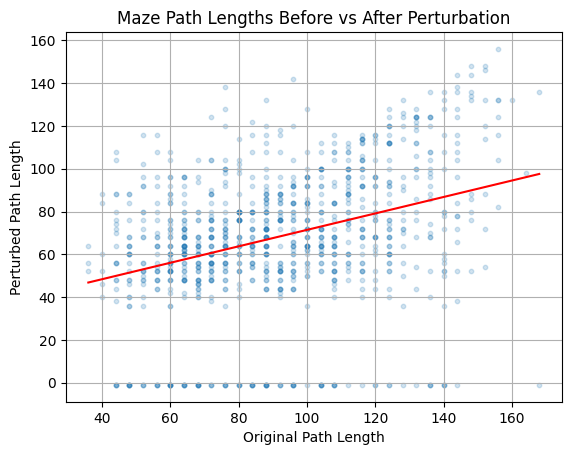

In [2]:
old_lengths, new_lengths = [], []

for _ in range(1000):
    maze = generate_maze(19, 19)
    old_len = maze_path_length(maze)
    new_maze = perturb_maze(maze)
    new_len = maze_path_length(new_maze)
    old_lengths.append(old_len)
    new_lengths.append(new_len)

plt.scatter(old_lengths, new_lengths, alpha=0.2, s=10)
plt.xlabel("Original Path Length")
plt.ylabel("Perturbed Path Length")
plt.title("Maze Path Lengths Before vs After Perturbation")
plt.plot(np.unique(old_lengths), np.poly1d(np.polyfit(old_lengths, new_lengths, 1))(np.unique(old_lengths)), color='red')
plt.grid(True)
plt.show()

# Generate training data

In [3]:
data = []
for _ in range(10000):
    maze = generate_maze(19, 19)
    orig_len = maze_path_length(maze)
    data.append([maze, orig_len])
    for _ in range(4):
        pert = perturb_maze(maze)
        pert_len = maze_path_length(pert)
        data.append([pert, pert_len])

with open("mazes.pkl", "wb") as f:
    pickle.dump(data, f)